# Phase 1: Data Exploration for Total Perspective Vortex
This notebook explores the PhysioNet EEG Motor Movement/Imagery Dataset. 

**Motor Execution vs. Motor Imagery:**
* **Motor Execution (ME):** The subject physically performs a movement (e.g., opening/closing a fist). This generates actual sensory-motor cortex activation.
* **Motor Imagery (MI):** The subject *imagines* performing the movement without any actual muscle activity. This is the core of our BCI pipeline. We aim to detect the Event-Related Desynchronization/Synchronization (ERD/ERS) in the alpha and beta bands that occurs during the *thought* of movement.

In [26]:
import os

In [27]:
print(os.getcwd())

/home/jvalenci/Desktop/Total-Perspective-Vortex/doc


In [28]:

from misc  import *

## Exploring raw data with a single subject and run 

In [29]:

# !Define your local data path (this should match your .gitignore)
data_path = "./mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0"

In [30]:
raw = load_eeg_data(subject_id=1, run_id=3, base_path=data_path)

Loading data from ./mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R03.edf...
Metadata verified: 160 Hz sampling rate, 64 channels, standard_1005 montage applied.


In [31]:
raw.get_data().shape

(64, 20000)


### **1. What `(64, 20000)` Means**

In **MNE-Python**, calling `raw.get_data()` returns a 2D NumPy array with the dimensions structured as **`(channels, time_points)`**:

* **`64` (Channels / Electrodes):**
This represents the **64 EEG scalp electrodes** recorded simultaneously using the BCI2000 international 10–10 system. Each row in the matrix corresponds to continuous voltage readings from one specific electrode (e.g., $C3$, $Cz$, $C4$, etc.).


* **`20000` (Time Points / Samples):**
This represents the total number of continuous discrete time samples recorded in that single run.

---

### **2. Calculating the Time Duration**

You can determine the exact recording duration in seconds using the dataset's sampling frequency ($f_s = 160\text{ Hz}$):

$$\text{Duration (seconds)} = \frac{\text{Total Time Points}}{\text{Sampling Rate}} = \frac{20{,}000\text{ samples}}{160\text{ samples/second}} = 125\text{ seconds}$$

* **Result:** **125 seconds** (or **2 minutes and 5 seconds**).
* **Dataset Context:** This matches the standard experimental design of the PhysioNet dataset, where each task run (Runs 3–14) lasts approximately **2 minutes** (120 seconds), plus a brief 5-second buffer at recording start/end.



---

### **3. Array Structure Summary**

| Dimension | Size | Description |
| --- | --- | --- |
| **Axis 0 (Rows)** | `64` | Electrodes/Channels recorded simultaneously across the scalp.

 |
| **Axis 1 (Columns)** | `20,000` | Temporal snapshots measured in Volts at 160 Hz.

 |

In [32]:
raw.get_data()

array([[-5.70e-05, -4.90e-05, -5.50e-05, ...,  0.00e+00,  0.00e+00,
         0.00e+00],
       [-1.30e-05, -1.10e-05, -1.70e-05, ...,  0.00e+00,  0.00e+00,
         0.00e+00],
       [-1.50e-05, -1.00e-05, -1.60e-05, ...,  0.00e+00,  0.00e+00,
         0.00e+00],
       ...,
       [-5.60e-05, -7.00e-05, -7.70e-05, ...,  0.00e+00,  0.00e+00,
         0.00e+00],
       [-1.24e-04, -1.49e-04, -1.53e-04, ...,  0.00e+00,  0.00e+00,
         0.00e+00],
       [-2.80e-05, -4.00e-05, -3.70e-05, ...,  0.00e+00,  0.00e+00,
         0.00e+00]], shape=(64, 20000))

## 1. Undestanding the Event Structure 

In [33]:
sub_dir = os.path.join(data_path, "S001")

In [34]:
sub_dir

'./mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001'

In [35]:
os.listdir(sub_dir)

['S001R04.edf',
 'S001R08.edf',
 'S001R12.edf',
 'S001R01.edf',
 'S001R02.edf',
 'S001R03.edf',
 'S001R07.edf',
 'S001R11.edf',
 'S001R05.edf',
 'S001R09.edf',
 'S001R13.edf',
 'S001R06.edf',
 'S001R10.edf',
 'S001R14.edf']

In [36]:
edf_files = sorted([f for f in os.listdir(sub_dir) if f.endswith(".edf")])

In [37]:
edf_files

['S001R01.edf',
 'S001R02.edf',
 'S001R03.edf',
 'S001R04.edf',
 'S001R05.edf',
 'S001R06.edf',
 'S001R07.edf',
 'S001R08.edf',
 'S001R09.edf',
 'S001R10.edf',
 'S001R11.edf',
 'S001R12.edf',
 'S001R13.edf',
 'S001R14.edf']

In [38]:
for f in  edf_files:
    file_path = os.path.join(sub_dir, f)
    # print(f.split("R")[1])
    print(f.split("R")[1].split(".")[0])
    # run_num = int(f.split("R")[1].split(".")[0])
    # print(run_num)

01
02
03
04
05
06
07
08
09
10
11
12
13
14


In [39]:

event_id = {"T0": 1, "T1": 2, "T2": 3}

In [40]:
for f in edf_files:

    file_path = os.path.join(sub_dir, f)

    raw_header = mne.io.read_raw_edf(file_path, preload=False, verbose="ERROR")

    events, _ = mne.events_from_annotations(raw_header, event_id=event_id,  verbose="ERROR")

    print(f"File: {f}, Number of Events: {len(events)}")
    print(f"time addition:{sum(events[:, 0])  }")

File: S001R01.edf, Number of Events: 1
time addition:0
File: S001R02.edf, Number of Events: 1
time addition:0
File: S001R03.edf, Number of Events: 30
time addition:288960
File: S001R04.edf, Number of Events: 30
time addition:288960
File: S001R05.edf, Number of Events: 30
time addition:288960
File: S001R06.edf, Number of Events: 30
time addition:288960
File: S001R07.edf, Number of Events: 30
time addition:288960
File: S001R08.edf, Number of Events: 30
time addition:288960
File: S001R09.edf, Number of Events: 30
time addition:288960
File: S001R10.edf, Number of Events: 30
time addition:288960
File: S001R11.edf, Number of Events: 30
time addition:288960
File: S001R12.edf, Number of Events: 30
time addition:288960
File: S001R13.edf, Number of Events: 30
time addition:288960
File: S001R14.edf, Number of Events: 30
time addition:288960


In [41]:

# Define exclusions based on known dataset issues
# Subject 88: Sampled at 128 Hz instead of 160 Hz
# Subjects 38, 89, 92, 100, 104, 106: Known annotation/event errors
# EXCLUDED_SUBJECTS = [38, 88, 89, 92, 100, 104, 106]
EXCLUDED_SUBJECTS = [ 88, 89, 92, 100, 104, 106]

# Parameters for our test subject
SUBJECT_TO_TEST = 38 
RUN_TO_TEST = 3  # Motor Imagery: Left vs Right Fist

# 106 ok, 

# Base directory for the unzipped dataset
BASE_DATA_PATH = "mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0"

In [42]:
# 1. Load the data
raw = load_eeg_data(SUBJECT_TO_TEST, RUN_TO_TEST, BASE_DATA_PATH)

Loading data from mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S038/S038R03.edf...
Metadata verified: 160 Hz sampling rate, 64 channels, standard_1005 montage applied.


## 2. Extract and map events

In [43]:

# 2. Map the events
events, event_dict, event_descriptions = extract_and_map_events(raw, RUN_TO_TEST)


Mapped Events for Run 3:
  Code 1: Rest (T0)
  Code 2: Opening/closing left fist (T1)
  Code 3: Opening/closing right fist (T2)


In [44]:
print(
    f"Event Dictionary: {event_dict} \n, Event Descriptions: {event_descriptions}\n, Number of Events: {len(events)} \n"
)

Event Dictionary: {np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3} 
, Event Descriptions: {1: 'Rest (T0)', 2: 'Opening/closing left fist (T1)', 3: 'Opening/closing right fist (T2)'}
, Number of Events: 30 



In [45]:
# Example to explore the first 5 events data structure 

print(f'Number of T0 events: {sum([1 for event in events if event[2] == 1])}')
print(f'Number of T1 events: {sum([1 for event in events if event[2] == 2])}')
print(f'Number of T2 events: {sum([1 for event in events if event[2] == 3])}')

Number of T0 events: 15
Number of T1 events: 7
Number of T2 events: 8


## mne Object type: info
* This display the metadata of the EEG data, including channel names, sampling frequency, and other relevant information.

**Acquisition**: Sampling frequency: 160 Hz
* 160 tims per second

**Channels**: EEG 64
* 64 electroencephalographic channles(electrodes) active and being recorded on the scalp

**Head & sensor digitization: 67 points**
* 67 3D spacial coordinate points where digitized (typically **64 electrode** locations plus **3 anatomical landmark points** - nasion, LPD, RPA)
    - **LPD** is the left preauricular point, is located just in fron of the left ear, as re reference point for electrode placement.
    - **RPA** is the right preauricular point, is located just in front of the right ear, as a reference point for electrode placement.
    - **Nasion** is the point on the skull where the frontal and nasal bones meet, located just above the bridge of the nose. It is used as a reference point for electrode placement and head coordinate system.

In [46]:
raw.info

<Info | 9 non-empty values
 bads: []
 ch_names: FC5, FC3, FC1, FCz, FC2, FC4, FC6, C5, C3, C1, Cz, C2, C4, C6, ...
 chs: 64 EEG
 custom_ref_applied: False
 dig: 67 items (3 Cardinal, 64 EEG)
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>

In [47]:
# extract the EEG channel names from the raw data
eeg_channels = raw.ch_names
print(f"total number of channels: {len(eeg_channels)}")

total number of channels: 64


In [48]:

print(f"EEG channels: {eeg_channels}")

EEG channels: ['FC5', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'FC6', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP5', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'CP6', 'Fp1', 'Fpz', 'Fp2', 'AF7', 'AF3', 'AFz', 'AF4', 'AF8', 'F7', 'F5', 'F3', 'F1', 'Fz', 'F2', 'F4', 'F6', 'F8', 'FT7', 'FT8', 'T7', 'T8', 'T9', 'T10', 'TP7', 'TP8', 'P7', 'P5', 'P3', 'P1', 'Pz', 'P2', 'P4', 'P6', 'P8', 'PO7', 'PO3', 'POz', 'PO4', 'PO8', 'O1', 'Oz', 'O2', 'Iz']


In [49]:
# Extract and count the digitized points (64 electrode locations + 3 anatomical landmark points)
dig_points = raw.info['dig']
print(f"total number of digitized points: {len(dig_points)}")

total number of digitized points: 67


* In order to know the type the channle we are dealing with, we use the 'kind' attribute of the channel info.
* the **'kind'** attribute is an **enumeration** that indicates the type of channel. 
* For **anatomical landmarks**, the kind is typically set to 1 
* For **EEG channels**, the kind is typically set to 3 (EEG).

In [50]:
# Extact anatomical landmark names (nasion, LPD, RPA)
fiducials = [p for p in dig_points if p['kind'] == 1]  # kind 1 corresponds to fiducial points
for p in fiducials:
    print(f"Fiducial point: {p['ident']}, Position: {p['r']}")
# !the position provides a 3D coordinate in meters (x, y, z) for each fiducial point.
# !'indent' attribute contains the name of the fiducial point

Fiducial point: 1 (FIFFV_POINT_LPA), Position: [-8.24899985e-02 -3.91308816e-09  9.39553990e-13]
Fiducial point: 2 (FIFFV_POINT_NASION), Position: [5.38337401e-09 1.14046625e-01 2.14553514e-11]
Fiducial point: 3 (FIFFV_POINT_RPA), Position: [ 8.24900134e-02  3.86007626e-09 -9.48421897e-13]


In [51]:
egg_points = [p for p in dig_points[:10] if p['kind'] == 3]  # kind 3 corresponds to EEG points
for p in egg_points:
    print(f"EEG point: {p['ident']}, Position: {p['r']}")

EEG point: 1, Position: [-0.03090259  0.11458518  0.02786657]
EEG point: 2, Position: [-0.00133733  0.1191018   0.0328899 ]
EEG point: 3, Position: [0.0284095  0.11534631 0.02772126]
EEG point: 5, Position: [-0.05636066  0.09915152  0.02514129]
EEG point: 7, Position: [-0.03518601  0.10912957  0.05643921]
EEG point: 9, Position: [-0.00123738  0.11373993  0.07038366]
EEG point: 11, Position: [0.03422986 0.10981127 0.05711667]


In [52]:
from collections import Counter

# Count how many points exist for each kind integer
kind_counts = Counter(int(p['kind']) for p in raw.info['dig'])

print("Digitization Summary:")
print(f" - kind 1 (Anatomical Fiducials): {kind_counts[1]} points")
print(f" - kind 3 (EEG Sensors):          {kind_counts[3]} points")
print(f"Total Digitized Points:           {sum(kind_counts.values())} points")

Digitization Summary:
 - kind 1 (Anatomical Fiducials): 3 points
 - kind 3 (EEG Sensors):          64 points
Total Digitized Points:           67 points


## Visualize the raw signals and plot the 3D scalp representation of the electrodes in MNE-Python

In [53]:
# retreive the 3D EEG data for subject 1, run 4
  # with the standard_1005 montage for better spatial representation
raw_3d_ex = load_eeg_data(1, 4, base_path=BASE_DATA_PATH, montage_type="standard_1005")

Loading data from mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R04.edf...
Metadata verified: 160 Hz sampling rate, 64 channels, standard_1005 montage applied.


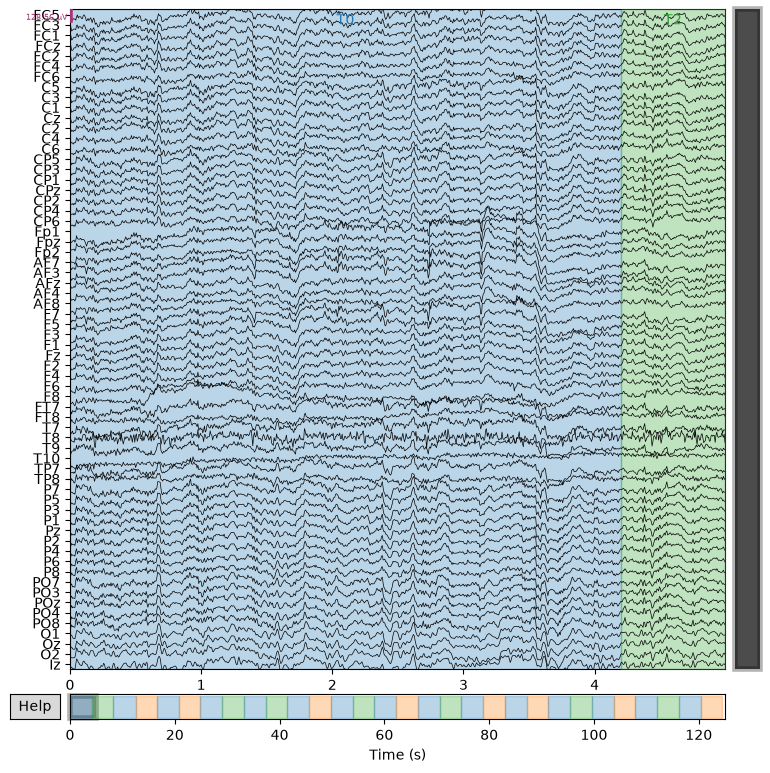

In [54]:
# Cell 4: Plotting the raw signals
# We specify n_channels=64 to see everything at once.
# duration=5.0 shows 5 seconds of data on the screen at a time.
# scalings='auto' automatically adjusts the vertical scale so the waves don't overlap too much.

fig_signals = raw_3d_ex.plot(
    n_channels=64, # we show all 64 channels at once
    duration=5.0, # it plots the first 5 seconds of data
    scalings="auto",
    title="Raw EEG Signals - All 64 Channels",
)


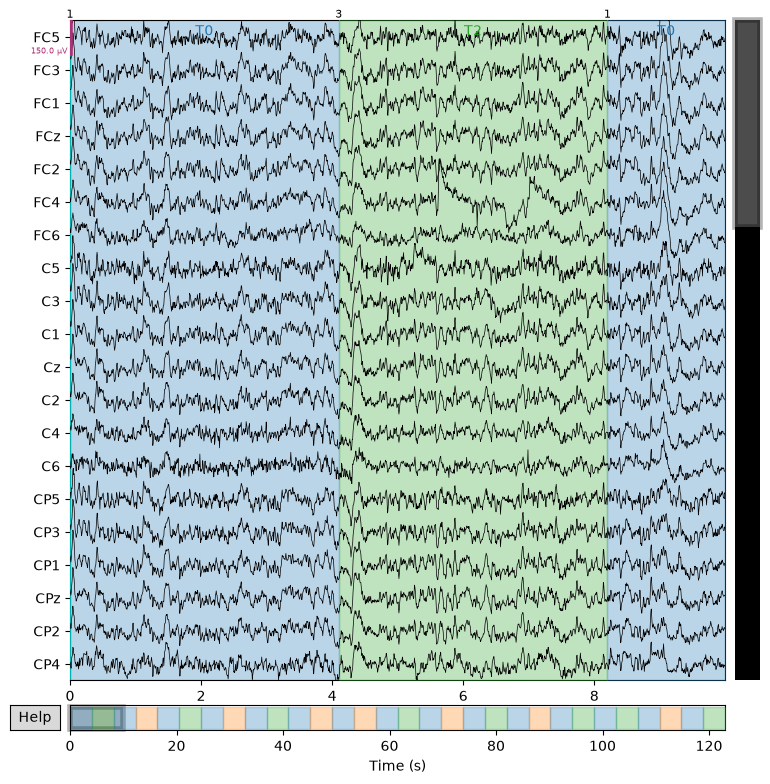

In [55]:



# 3. Visualize Raw Continuous Signal with Events
# Note: In a Jupyter Notebook, %matplotlib widget or qt can make this fully interactive.
# We set scalings='auto' or a specific microvolt dictionary so signals don't overlap.
fig_raw = raw.plot(
    events=events, 
    start=0, 
    duration=10, # it plots the first 10 seconds of data 
    # n_channels sets how many channels to display at once; adjust for visibility
    n_channels=20, 
    scalings={'eeg': 75e-6}, # Scale to 75 microvolts for better visibility
    title=f"Subject {SUBJECT_TO_TEST} Run {RUN_TO_TEST} - Raw EEG (First 10s)",
    show=True
)

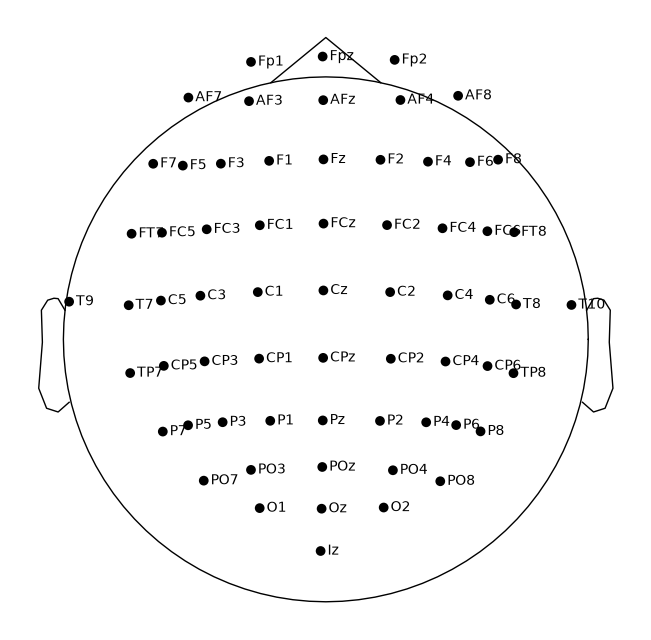

In [56]:
# Cell 5: Plotting the 3D Scalp representation
# kind='3d' generates the 3D sphere/head model.
# show_names=True prints the channel labels (e.g., 'Cz', 'Pz') next to the dots.
# !ch_type: 'eeg' specifies that we want to visualize EEG channels specifically.
# !show_names: True ensures that the channel names are displayed on the 3D plot.
fig_3d = raw_3d_ex.plot_sensors(kind='topomap', ch_type="eeg", show_names=True)

# Note: In an interactive notebook, you can click and drag this image to rotate the 3D head!

## Power Spectral Density (PSD) Analysis
* We can compute the PSD to see how power is distributed across frequencies.
* The PSD is computed using Welch's method, which averages periodograms to reduce noise. 

/home/jvalenci/Desktop/Total-Perspective-Vortex/.env/lib/python3.13/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


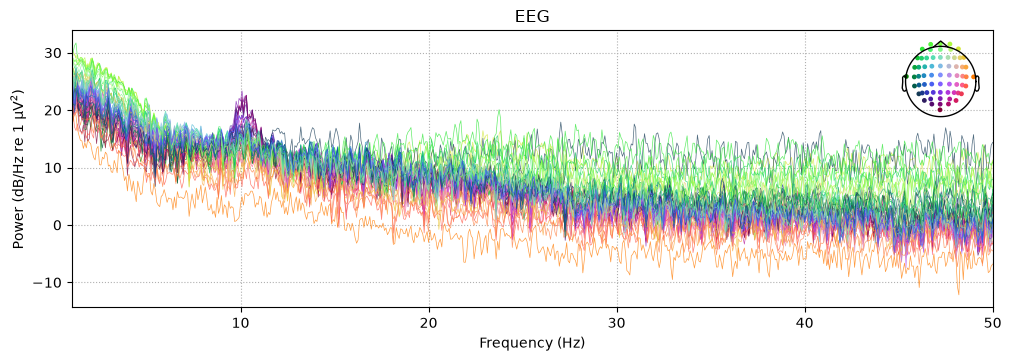

<Figure size 2000x500 with 0 Axes>

In [ ]:

# 4. Visualize Power Spectral Density (PSD)
# We limit frequencies between 1 Hz and 50 Hz to focus on Alpha (8-13 Hz) and Beta (14-30 Hz)
# because these bands are the most relevant for congnitive state analysis due to the fact 
#  ?these frequecies are the most prominent or significant in EEG signals
#  ?because they are asociated to congniteve processs such as motor imagery and motor movement
# !This is crucial for feature selection in Phase 1.
# ?fmin:  means the minimum frequency to include in the PSD calculation
# ? fmax:  means the maximum frequency to include in the PSD calculation
fig_psd = raw.compute_psd(fmin=1.0, fmax=50.0).plot(
    # picks means which channels to include in the PSD calculation. 
        # 'eeg' includes all EEG channels.
    picks='eeg', 
    # excluce bad channles from the PSD calculation.
        # * bad channels are those that have been marked as noisy
    show=True
)

# Add supplementary static visualization of event timing using Matplotlib
# sizefigure=(20, 5) sets the figure size to 20 inches wide and 5 inches tall.
plt.figure(figsize=(20, 5))
plt.show()

### 1. The Axes

* **X-Axis (Frequency in Hz):** Represents the frequency of the brainwaves, ranging from 0 to 50 Hz. Different frequency bands correspond to distinct cognitive states <span style="color: red;"><b>(e.g., Alpha is 8–12 Hz, Beta is 13–30 Hz)</b></span>.

* **Y-Axis (Power in dB/Hz):** This measures the strength or "loudness" of the signal at that specific frequency. It is on a logarithmic scale (decibels) because lower frequencies naturally have vastly higher power than high frequencies.

### 2. The Lines and the Head Map (Inset)

* Every single squiggly line represents one of your 64 electrodes.
* The small head model in the top right is your color legend. The color of a line corresponds to its physical location on the scalp. For example:
* **Green/Yellow lines:** Frontal electrodes (near the forehead).
* **Purple/Dark Blue lines:** Occipital/Parietal electrodes (at the back of the head).



### 3. Key Takeaways from the Data Shape

* **The 1/f Drop-off:** Notice how all the lines start very high on the left and curve downward as they move right. This is a universal characteristic of human brainwaves; slow waves carry the most amplitude, and fast waves carry the least.
* **The Alpha Peak (~10 Hz):** Look closely at the 10 to 12 Hz mark. You will see a distinct "hump" or peak that interrupts the downward curve, particularly in the purple and dark pink lines. This is the **Alpha rhythm**. Because it is strongest in the purple channels, it tells us the subject had high visual relaxation (Alpha waves are strongest in the visual cortex at the back of the head when resting or eyes are closed).


# Deep-Dive EDA: Dataset Hierarchy & Signal Granularity

To build a robust BCI, we must understand the data at every scale. The PhysioNet EEG Motor Movement/Imagery Dataset is organized in a strict hierarchy:

1.  **Subject (1 to 109)**: Each subject has unique anatomical and neural characteristics.
2.  **Run (1 to 14)**: Each run targets a specific task type. We focus on **Motor Imagery (MI)** runs:
    *   **Runs 4, 8, 12**: Imaging opening/closing left or right fist.
3.  **Event (T0, T1, T2)**: Annotations within a run marking the intent:
    *   **T0**: Rest/Baseline.
    *   **T1**: Intent to move Left Fist.
    *   **T2**: Intent to move Right Fist.
4.  **Channel (64 Electrodes)**: Spatial snapshots across the scalp (Standard 10-10 system).
5.  **Voltage Snapshot (160 Hz)**: The most granular level—discrete voltage readings every 6.25ms.

In this step, we load a clean Motor Imagery run (Subject 1, Run 4) and inspect its macro-level metadata.

In [4]:

# 1. Define the hierarchy level: Subject 1, Run 4 (Motor Imagery)
SUBJECT_ID = 1
RUN_ID = 4  # Task: Motor Imagery (Left vs Right Fist)

# 2. Path to our local data store
DATA_PATH = "./mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0"

# 3. Load the data using the custom project transformer logic
raw = load_eeg_data(subject_id=SUBJECT_ID, run_id=RUN_ID, base_path=DATA_PATH)

# 4. Display macro-level metadata
print("-" * 30)
print(f"Hierarchical Level: Subject {SUBJECT_ID}, Run {RUN_ID}")
print(f"Total Duration: {raw.times[-1]:.2f} seconds")
print(f"Sampling Frequency: {raw.info['sfreq']} Hz")
print(f"Number of Channels: {len(raw.ch_names)}")
print("-" * 30)

# Briefly peek at the mne.Info object for full metadata verification
raw.info

Loading data from ./mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R04.edf...
Metadata verified: 160 Hz sampling rate, 64 channels, standard_1005 montage applied.
------------------------------
Hierarchical Level: Subject 1, Run 4
Total Duration: 124.99 seconds
Sampling Frequency: 160.0 Hz
Number of Channels: 64
------------------------------


<Info | 9 non-empty values
 bads: []
 ch_names: FC5, FC3, FC1, FCz, FC2, FC4, FC6, C5, C3, C1, Cz, C2, C4, C6, ...
 chs: 64 EEG
 custom_ref_applied: False
 dig: 67 items (3 Cardinal, 64 EEG)
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>

### Step 2: Event Extraction & Timeline Mapping

In this step, we extract the annotations from the EDF+ file. For Run 4, the mapping is:
*   **T0 (Rest)**: The subject is resting.
*   **T1 (Left Imagery)**: The subject imagines opening and closing their left fist.
*   **T2 (Right Imagery)**: The subject imagines opening and closing their right fist.

We will visualize the **chronological timeline** to see how trials are distributed across the 125-second recording. We expect to see approximately 15 trials per movement type, interleaved with rest periods.

In [16]:
from misc import extract_and_map_events
import matplotlib.pyplot as plt

# 1. Extract and map the events
# event_descriptions uses integer codes (1, 2, 3) as keys
events, event_dict, event_descriptions = extract_and_map_events(raw, RUN_ID)


Mapped Events for Run 4:
  Code 1: Rest (T0)
  Code 2: Imagine Left Fist (T1)
  Code 3: Imagine Right Fist (T2)


In [17]:
events

array([[    0,     0,     1],
       [  672,     0,     3],
       [ 1328,     0,     1],
       [ 2000,     0,     2],
       [ 2656,     0,     1],
       [ 3328,     0,     2],
       [ 3984,     0,     1],
       [ 4656,     0,     3],
       [ 5312,     0,     1],
       [ 5984,     0,     3],
       [ 6640,     0,     1],
       [ 7312,     0,     2],
       [ 7968,     0,     1],
       [ 8640,     0,     3],
       [ 9296,     0,     1],
       [ 9968,     0,     2],
       [10624,     0,     1],
       [11296,     0,     3],
       [11952,     0,     1],
       [12624,     0,     2],
       [13280,     0,     1],
       [13952,     0,     2],
       [14608,     0,     1],
       [15280,     0,     3],
       [15936,     0,     1],
       [16608,     0,     2],
       [17264,     0,     1],
       [17936,     0,     3],
       [18592,     0,     1],
       [19264,     0,     2]])

### Column Breakdown

1. **Column 1: Sample Index (Timestamp in samples, NOT seconds)**
* This is the exact sample point at which the event occurred.
* To convert a sample index to time in seconds, divide by your sampling frequency ($160\text{ Hz}$):
* Sample `0` $\rightarrow$ $0 / 160 = \mathbf{0.0\text{ seconds}}$
* Sample `672` $\rightarrow$ $672 / 160 = \mathbf{4.2\text{ seconds}}$
* Sample `1328` $\rightarrow$ $1328 / 160 = \mathbf{8.3\text{ seconds}}$
* Sample `2000` $\rightarrow$ $2000 / 160 = \mathbf{12.5\text{ seconds}}$
* Sample `2656` $\rightarrow$ $2656 / 160 = \mathbf{16.6\text{ seconds}}$




2. **Column 2: Previous Event / Duration Flag (Always `0` here)**
* This column records the previous state or duration marker in digital triggers. For standard EDF annotations parsed by MNE, it remains `0`.


3. **Column 3: Event ID Code**
* This is the numerical code mapped to the event type.
* **`1`**: `T0` (Rest / Baseline)
* **`2`**: `T1` (Left Fist action or motor imagery)
* **`3`**: `T2` (Right Fist action or motor imagery)

In [18]:
event_dict

{np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}

In [19]:
event_descriptions

{1: 'Rest (T0)', 2: 'Imagine Left Fist (T1)', 3: 'Imagine Right Fist (T2)'}

In [21]:

# 2. Print event counts for verification
print("Event Counts:")
# iterate throught the event dictionary (key: label)
for label, event_id in event_dict.items():
    count = (events[:, 2] == event_id).sum()
    # Fixed: Use integer event_id as key for event_descriptions
    print(f" - {label} ({event_descriptions[event_id]}): {count} trials")

Event Counts:
 - T0 (Rest (T0)): 15 trials
 - T1 (Imagine Left Fist (T1)): 8 trials
 - T2 (Imagine Right Fist (T2)): 7 trials


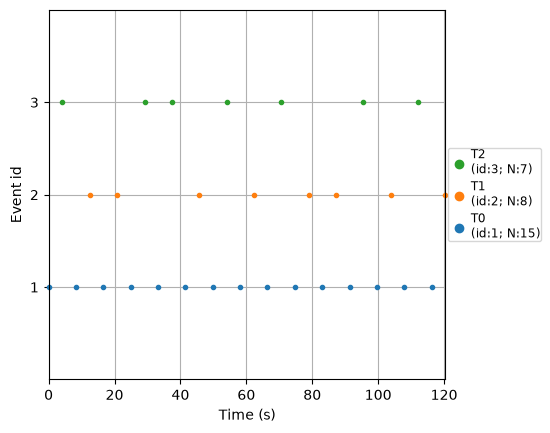

In [23]:

# 3. Plot the event timeline
fig_events = mne.viz.plot_events(
    events, 
    sfreq=raw.info['sfreq'], 
    first_samp=raw.first_samp, 
    event_id=event_dict,
    # title=f"Event Timeline - Subject {SUBJECT_ID}, Run {RUN_ID}"
)

### Step 3: Spatial & Temporal Granularity (The Snapshot)

At 160 Hz, we capture a voltage reading every **6.25 milliseconds**. To visualize the signal's microstructure, we will:
1.  **Identify a single Motor Imagery trial** (e.g., the first T1 - Left Fist Imagery).
2.  **Slice a 3-second window** around that event.
3.  **Compare Raw vs. Filtered signals**:
    *   **Raw**: High-frequency noise and low-frequency drifts may be visible.
    *   **Filtered (8-30 Hz)**: Isolates the Mu and Beta bands where motor imagery features reside.
4.  **Focus on Motor Cortex Channels**: We pick **C3 (Right-hand control area)**, **Cz (Vertex)**, and **C4 (Left-hand control area)**. In motor imagery, we expect to see contra-lateral desynchronization (e.g., C4 power drop during Left Fist imagery).

In [ ]:
import numpy as np

# Creates the indices of the events that correspond to T1 (event code 2) in the events array.
t1_indices = np.where(events[:, 2] == event_dict['T1'])[0]


In [25]:
t1_indices

array([ 3,  5, 11, 15, 19, 21, 25, 29])

In [32]:
events

array([[    0,     0,     1],
       [  672,     0,     3],
       [ 1328,     0,     1],
       [ 2000,     0,     2],
       [ 2656,     0,     1],
       [ 3328,     0,     2],
       [ 3984,     0,     1],
       [ 4656,     0,     3],
       [ 5312,     0,     1],
       [ 5984,     0,     3],
       [ 6640,     0,     1],
       [ 7312,     0,     2],
       [ 7968,     0,     1],
       [ 8640,     0,     3],
       [ 9296,     0,     1],
       [ 9968,     0,     2],
       [10624,     0,     1],
       [11296,     0,     3],
       [11952,     0,     1],
       [12624,     0,     2],
       [13280,     0,     1],
       [13952,     0,     2],
       [14608,     0,     1],
       [15280,     0,     3],
       [15936,     0,     1],
       [16608,     0,     2],
       [17264,     0,     1],
       [17936,     0,     3],
       [18592,     0,     1],
       [19264,     0,     2]])

In [31]:
events[t1_indices[0]] 

array([2000,    0,    2])

In [27]:

# Gets the first sample index of the first t1 event from the events array, column 0 contains the sample indices of the events.
first_t1_sample = events[t1_indices[0], 0]
first_t1_sample


np.int64(2000)

In [33]:

# Calculates the start time in seconds for the first T1 event by dividing the sample index by the sampling frequency 160 Hz.
    # this gives us the time in seconds at which the first T1 event occurs in the raw EEG data.
t_start = first_t1_sample / raw.info['sfreq']
t_start

np.float64(12.5)

In [34]:
# Then we define the end time for our snapshot, which is 3 seconds after the start time.
t_end = t_start + 3.0  # 3-second snapshot
t_end

np.float64(15.5)

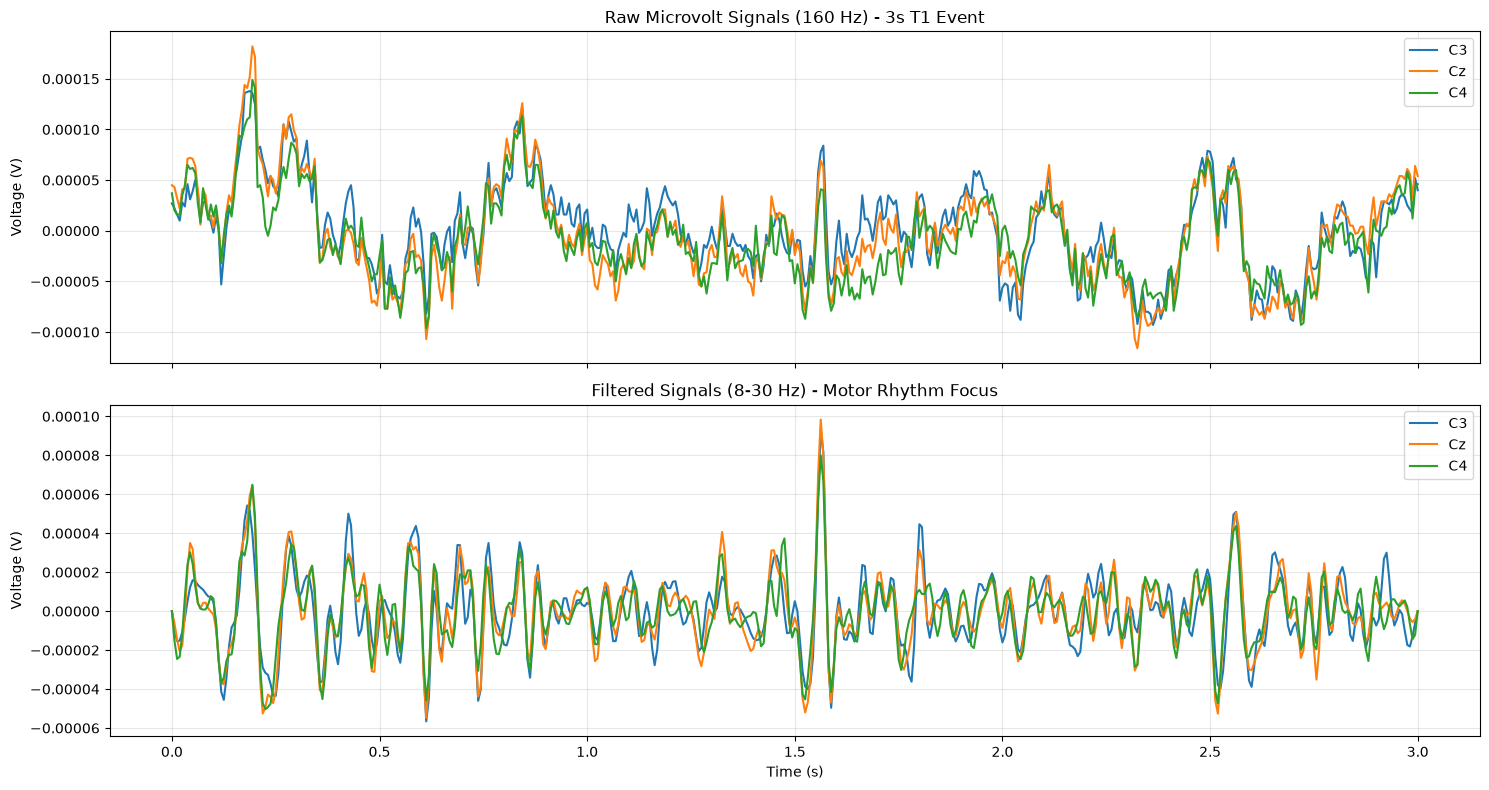

In [ ]:

# 2. Select relevant Motor Cortex channels
picks = ['C3', 'Cz', 'C4']

# 3. here we extract a 3- second slice of the raw EEG data for the selected channels (C3, Cz, C4) around the first T1 event.
raw_slice = raw.copy().pick(picks).crop(t_start, t_end)

#  4. then filter the raw slice to create a filtered slice (8-30 Hz band-pass) 
    # fir_design='figwin' prevents distortion by using an special technique when filtering the signal. 
filtered_slice = raw_slice.copy().filter(8, 30, fir_design='firwin', verbose='ERROR')

# 5. Create a comparison plot of the raw and filtered signals.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# Plot Raw
    # *  Plot each channel
for i, ch in enumerate(picks):
    # * on x axis represents the time stamps of the raw EEG data for each channel (C3, Cz, C4) over the 3-second snapshot.
    # * on y axis we show the voltage values of the raw EEG data for each channel (C3, Cz, C4) over the 3-second snapshot.
    ax1.plot(raw_slice.times, raw_slice.get_data()[i], label=ch)
ax1.set_title(f"Raw Microvolt Signals (160 Hz) - 3s T1 Event")
ax1.set_ylabel("Voltage (V)")
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)


# Plot Filtered
for i, ch in enumerate(picks):
    # * on x axis represents the time stamps of the raw EEG data for each channel (C3, Cz, C4) over the 3-second snapshot.
    # * on y axis we show the voltage values of the raw EEG data for each channel (C3, Cz, C4) over the 3-second snapshot.
    ax2.plot(filtered_slice.times, filtered_slice.get_data()[i], label=ch)
ax2.set_title(f"Filtered Signals (8-30 Hz) - Motor Rhythm Focus")
ax2.set_ylabel("Voltage (V)")
ax2.set_xlabel("Time (s)")
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:

print(f"Snapshot Details:")
print(f" - Start Time: {t_start:.2f}s")
print(f" - Duration: 3.0 seconds ({len(raw_slice.times)} samples)")
print(f" - Frequency Resolution: 1/160s = 6.25ms per point")